# Fig. S22 | Local recovery, persistence and management leverage

Maps the three Cell-scale response metrics and compares their distributions across the F, S and B recovery classes.


In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from pyproj import Geod, Transformer
from scipy.ndimage import generic_filter
from shapely.geometry import LineString

ROOT = next(path.resolve() for path in [Path.cwd(), *Path.cwd().parents]
            if (path / 'src' / 'reconstruct.py').exists())
SOURCE_DIR = ROOT / 'outputs' / 'MANAGEMENT_2012_2013' / 'local_response'
OUT_DIR = ROOT / 'outputs' / 'figures' / 'FigS22'
OUT_DIR.mkdir(parents=True, exist_ok=True)
CELL_METRICS_PATH = SOURCE_DIR / 'cell_metrics.csv.gz'
MRVA_BOUNDARY_PATH = ROOT / 'assets' / 'spatial' / 'mrva_boundary.geojson'
MISSISSIPPI_RIVER_GMT_PATH = ROOT / 'assets' / 'spatial' / 'mississippi_river.gmt'
GRID_CRS = 'EPSG:5070'
LONLAT_CRS = 'EPSG:4326'
EXPORT_DPI = 600
MAP_BOUNDARY_COLOR = '#1F1F1F'
MAP_BOUNDARY_LW = 0.45
MAP_RIVER_COLOR = '#B7DDE8'
MAP_RIVER_LW = 0.42
SCALEBAR_GEOD = Geod(ellps='WGS84')

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif'],
    'font.size': 9.0,
    'axes.labelsize': 9.0,
    'axes.titlesize': 10.0,
    'xtick.labelsize': 8.0,
    'ytick.labelsize': 8.0,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})


## Load validated Cell metrics


In [2]:
cell_metrics = pd.read_csv(CELL_METRICS_PATH)
required = {
    'grid_id', 'x', 'y', 'own_unit_response_dec2012_m',
    'own_unit_persistence_fraction', 'management_leverage',
}
missing = sorted(required.difference(cell_metrics.columns))
if missing:
    raise ValueError(f'Missing Fig. S22 columns: {missing}')
print(f'Loaded {len(cell_metrics):,} active 1-km Cells.')


Loaded 87,871 active 1-km Cells.


## Figure


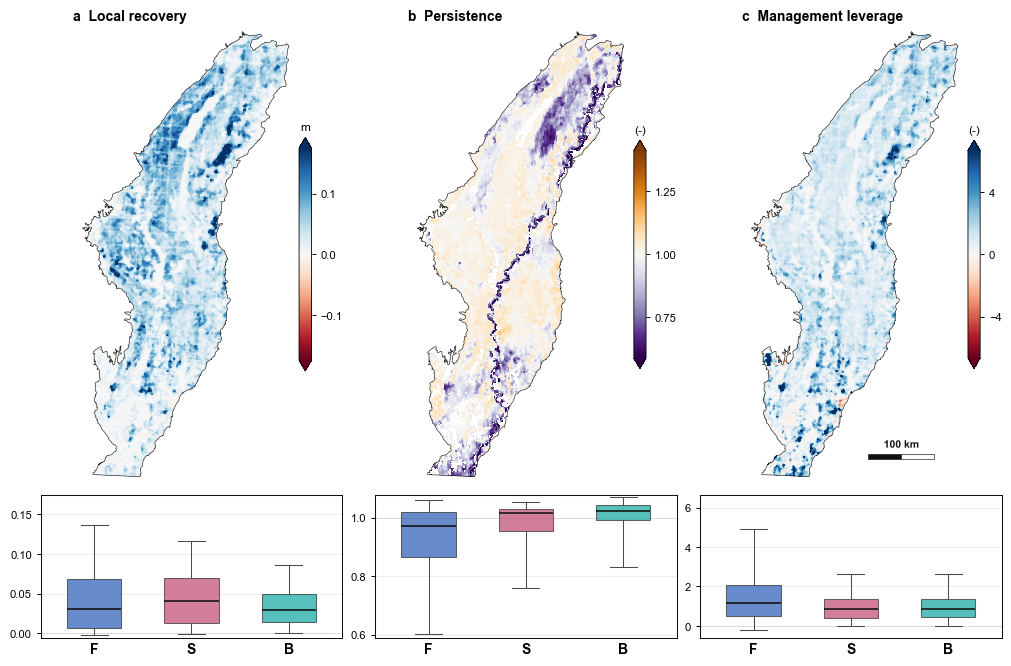

In [3]:
panels = [
    (
        'own_unit_response_dec2012_m', 'a  Local recovery',
        'm', 'RdBu', (0.01, 0.99), 0.0,
    ),
    (
        'own_unit_persistence_fraction', 'b  Persistence',
        '(-)', 'PuOr_r', (0.02, 0.98), 1.0,
    ),
    (
        'management_leverage', 'c  Management leverage',
        '(-)', 'RdBu', (0.01, 0.99), 0.0,
    ),
]

CLASS_LABELS_PATH = ROOT / 'outputs' / 'RECON_MAIN_2011_2023' / 'metrics' / 'clustering' / 'cluster_labels.csv'
class_labels = pd.read_csv(
    CLASS_LABELS_PATH, usecols=['grid_id', 'valid_for_clustering', 'response_class'],
)
class_metrics = cell_metrics.merge(class_labels, on='grid_id', how='left', validate='one_to_one')
class_metrics = class_metrics.loc[
    class_metrics['valid_for_clustering'].fillna(False)
    & class_metrics['response_class'].notna()
].copy()
CLASS_ORDER = ['Fast recovery', 'Slow recovery', 'Buffered']
CLASS_SHORT = {'Fast recovery': 'F', 'Slow recovery': 'S', 'Buffered': 'B'}
CLASS_COLORS = {'Fast recovery': '#2D5FB8', 'Slow recovery': '#C44E72', 'Buffered': '#13A8A2'}

n_rows = int(cell_metrics['row'].max()) + 1
n_cols = int(cell_metrics['col'].max()) + 1
rows = cell_metrics['row'].to_numpy(dtype=int)
cols = cell_metrics['col'].to_numpy(dtype=int)
x_by_col = cell_metrics.groupby('col')['x'].first().sort_index().to_numpy(dtype=float)
y_by_row = cell_metrics.groupby('row')['y'].first().sort_index().to_numpy(dtype=float)
dx = float(np.nanmedian(np.diff(x_by_col)))
dy = float(np.nanmedian(np.diff(y_by_row)))
x_edges = np.concatenate([[x_by_col[0] - 0.5 * dx], x_by_col + 0.5 * dx])
y_edges = np.concatenate([[y_by_row[0] - 0.5 * dy], y_by_row + 0.5 * dy])
xx, yy = np.meshgrid(x_edges, y_edges)
transformer = Transformer.from_crs(GRID_CRS, LONLAT_CRS, always_xy=True)
MAP_LON_EDGES, MAP_LAT_EDGES = map(np.asarray, transformer.transform(xx, yy))
MAP_EXTENT = (
    float(np.nanmin(MAP_LON_EDGES)), float(np.nanmax(MAP_LON_EDGES)),
    float(np.nanmin(MAP_LAT_EDGES)), float(np.nanmax(MAP_LAT_EDGES)),
)
boundary = gpd.read_file(MRVA_BOUNDARY_PATH).to_crs(LONLAT_CRS)
MRVA_POLYGON = boundary.geometry.union_all() if hasattr(boundary.geometry, 'union_all') else boundary.unary_union

def read_gmt_segments(path):
    segments, current = [], []
    for line in path.read_text(encoding='utf-8').splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith('>'):
            if current:
                segments.append(np.asarray(current, dtype=float))
                current = []
            continue
        lon, lat = line.split()[:2]
        current.append((float(lon), float(lat)))
    if current:
        segments.append(np.asarray(current, dtype=float))
    return segments

MISSISSIPPI_SEGMENTS = read_gmt_segments(MISSISSIPPI_RIVER_GMT_PATH)

def plot_geometry(ax, geometry, **kwargs):
    if geometry is None or geometry.is_empty:
        return
    if geometry.geom_type == 'LineString':
        x, y = geometry.xy
        ax.plot(np.asarray(x), np.asarray(y), **kwargs)
    elif geometry.geom_type in {'MultiLineString', 'GeometryCollection'}:
        for part in geometry.geoms:
            plot_geometry(ax, part, **kwargs)
    elif geometry.geom_type == 'Polygon':
        plot_geometry(ax, geometry.boundary, **kwargs)
    elif geometry.geom_type == 'MultiPolygon':
        for part in geometry.geoms:
            plot_geometry(ax, part.boundary, **kwargs)

def draw_map_context(ax):
    for segment in MISSISSIPPI_SEGMENTS:
        if len(segment) >= 2:
            clipped = LineString(segment).intersection(MRVA_POLYGON)
            plot_geometry(ax, clipped, color=MAP_RIVER_COLOR, lw=MAP_RIVER_LW, alpha=0.95, zorder=3)
    plot_geometry(ax, MRVA_POLYGON.boundary, color=MAP_BOUNDARY_COLOR, lw=MAP_BOUNDARY_LW, zorder=4)

def format_map_axis(ax):
    ax.set_xlim(MAP_EXTENT[0], MAP_EXTENT[1])
    ax.set_ylim(MAP_EXTENT[2], MAP_EXTENT[3])
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    mean_lat = 0.5 * (MAP_EXTENT[2] + MAP_EXTENT[3])
    ax.set_aspect(1.0 / np.cos(np.deg2rad(mean_lat)))

def draw_scale_bar(ax, length_km=100, anchor=(0.58, 0.055)):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    lon0 = xmin + anchor[0] * (xmax - xmin)
    lat0 = ymin + anchor[1] * (ymax - ymin)
    lon1, _, _ = SCALEBAR_GEOD.fwd(lon0, lat0, 90, length_km * 1000)
    width = lon1 - lon0
    height = 0.010 * (ymax - ymin)
    for index, color in enumerate(['#111111', '#FFFFFF']):
        ax.add_patch(Rectangle(
            (lon0 + index * width / 2, lat0), width / 2, height,
            facecolor=color, edgecolor='#111111', linewidth=0.45, clip_on=False, zorder=8,
        ))
    ax.text(
        lon0 + width / 2, lat0 + 2.0 * height, f'{length_km} km',
        ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='#111111',
        clip_on=False, path_effects=[pe.withStroke(linewidth=1.6, foreground='white')], zorder=9,
    )

def rasterize(values):
    raster = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
    raster[rows, cols] = np.asarray(values, dtype=np.float32)
    return raster

def median_filter(values):
    raster = rasterize(values)
    def finite_median(window):
        finite = window[np.isfinite(window)]
        return float(np.median(finite)) if finite.size else np.nan
    display = generic_filter(raster, finite_median, size=3, mode='nearest')
    display[~np.isfinite(raster)] = np.nan
    return display

fig = plt.figure(figsize=(10.0, 6.55), layout='constrained')
grid = fig.add_gridspec(2, 3, height_ratios=[4.9, 1.45], hspace=0.04)
map_axes, color_axes = [], []
for index in range(3):
    map_grid = grid[0, index].subgridspec(1, 2, width_ratios=[0.90, 0.040], wspace=0.000)
    map_axes.append(fig.add_subplot(map_grid[0, 0]))
    color_axes.append(fig.add_subplot(map_grid[0, 1]))
box_axes = [fig.add_subplot(grid[1, index]) for index in range(3)]

for panel_index, (axis, color_axis, box_axis, panel) in enumerate(zip(map_axes, color_axes, box_axes, panels)):
    column, title, colorbar_unit, cmap_name, robust_quantiles, center = panel
    values = cell_metrics[column].to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        raise ValueError(f'No finite Cell values for {column}.')
    display_min, display_max = map(float, np.quantile(finite, robust_quantiles))
    if center is not None and display_min < center < display_max:
        bound = max(center - display_min, display_max - center)
        norm = TwoSlopeNorm(vmin=center - bound, vcenter=center, vmax=center + bound)
    else:
        norm = Normalize(vmin=display_min, vmax=display_max)
    cmap = mpl.colormaps[cmap_name].copy()
    cmap.set_bad('#FFFFFF')
    image = axis.pcolormesh(
        MAP_LON_EDGES, MAP_LAT_EDGES, median_filter(values),
        cmap=cmap, norm=norm, shading='flat', rasterized=True,
    )
    draw_map_context(axis)
    format_map_axis(axis)
    axis.set_anchor('E')
    axis.set_title(title, loc='left', fontweight='bold', pad=3)
    color_axis.set_box_aspect(17)
    color_axis.set_anchor('W')
    colorbar = fig.colorbar(image, cax=color_axis, orientation='vertical', extend='both')
    colorbar.ax.set_title(colorbar_unit, pad=5, fontsize=8.5)
    colorbar.locator = mpl.ticker.MaxNLocator(nbins=4)
    colorbar.update_ticks()
    colorbar.ax.tick_params(length=2.8, width=0.65, labelsize=8.0)
    colorbar.outline.set_linewidth(0.6)

    class_values = [
        class_metrics.loc[class_metrics['response_class'] == class_name, column]
        .dropna().to_numpy(dtype=float)
        for class_name in CLASS_ORDER
    ]
    boxplot = box_axis.boxplot(
        class_values, positions=np.arange(1, 4), widths=0.56, patch_artist=True,
        whis=(5, 95), showfliers=False,
        medianprops={'color': '#111111', 'linewidth': 1.15},
        whiskerprops={'color': '#4A4A4A', 'linewidth': 0.75},
        capprops={'color': '#4A4A4A', 'linewidth': 0.75},
    )
    for class_name, patch in zip(CLASS_ORDER, boxplot['boxes']):
        patch.set_facecolor(CLASS_COLORS[class_name])
        patch.set_edgecolor('#333333')
        patch.set_linewidth(0.75)
        patch.set_alpha(0.72)
    if center is not None and display_min < center < display_max:
        box_axis.axhline(center, color='#666666', linewidth=0.55, linestyle='--', alpha=0.55, zorder=0)
    box_axis.set_xlim(0.45, 3.55)
    box_axis.set_ylim(display_min, display_max)
    box_axis.set_xticks(np.arange(1, 4), labels=[CLASS_SHORT[name] for name in CLASS_ORDER])
    for label in box_axis.get_xticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(10)
    box_axis.locator_params(axis='y', nbins=4)
    box_axis.grid(axis='y', color='#E6E2DA', linewidth=0.55, alpha=0.75, zorder=0)
    box_axis.set_axisbelow(True)
    for spine in box_axis.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.75)
        spine.set_color('#111111')
    box_axis.tick_params(axis='x', length=0, pad=3)
    box_axis.tick_params(axis='y', length=2.8, width=0.75)

draw_scale_bar(map_axes[2], length_km=100)
fig.savefig(OUT_DIR / 'FigS22.png', dpi=EXPORT_DPI, bbox_inches='tight', pad_inches=0.04)
plt.show()


The source intervention was applied one Unit at a time, whereas every mapped and summarized response remains a 1-km Cell value.
